In [1]:
# --- 1. Import Library ---
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay


In [2]:
# --- 2. Load Dataset ---
# Upload file CSV di Google Colab
from google.colab import files
uploaded = files.upload()


Saving survey lung cancer.csv to survey lung cancer.csv


In [3]:
# Asumsikan nama file: survey lung cancer.csv
df = pd.read_csv('survey lung cancer.csv')
print("Dataset Loaded:")
print(df.head())

Dataset Loaded:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2      

In [6]:
df.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES
308,M,62,1,1,1,2,1,2,2,2,2,1,1,2,1,YES


In [7]:
# --- 3. Preprocessing ---
# Encode categorical data
le = LabelEncoder()
df['GENDER'] = le.fit_transform(df['GENDER'])     # 'M', 'F' -> 1, 0
df['LUNG_CANCER'] = le.fit_transform(df['LUNG_CANCER'])  # 'YES', 'NO' -> 1, 0

Encode kolom kategorikal menjadi angka:

GENDER: "M" dan "F" menjadi 1 dan 0

LUNG_CANCER: "YES" dan "NO" menjadi 1 dan 0

In [8]:
# Pisahkan fitur dan target
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

Memisahkan fitur (X) dan target/label (y)

In [9]:
# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Normalisasi fitur agar semua nilai dalam skala yang sama – penting untuk KNN.

In [10]:
# Split data: train/test = 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Split data jadi training (80%) dan testing (20%) untuk evaluasi model.

In [12]:
# --- 4. Modeling dan Evaluasi ---

In [11]:
# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)


Membuat dan melatih model Naive Bayes, lalu melakukan prediksi pada test set.

In [13]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

Melatih model KNN (dengan k=5) untuk klasifikasi dan prediksi.

In [14]:
# Akurasi
nb_acc = accuracy_score(y_test, nb_preds)
knn_acc = accuracy_score(y_test, knn_preds)

 Menghitung akurasi model (persentase prediksi yang benar).

Text(0.5, 1.0, 'Naive Bayes\nAccuracy: 0.95')

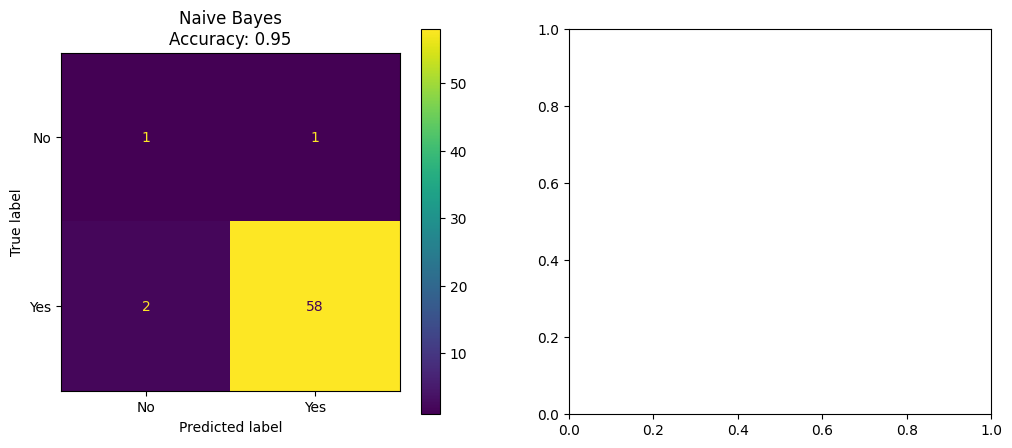

In [15]:
# Confusion Matrix
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, nb_preds), display_labels=['No', 'Yes']).plot(ax=axs[0])
axs[0].set_title(f'Naive Bayes\nAccuracy: {nb_acc:.2f}')

In [16]:
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_preds), display_labels=['No', 'Yes']).plot(ax=axs[1])
axs[1].set_title(f'KNN (k=5)\nAccuracy: {knn_acc:.2f}')

Text(0.5, 1.0, 'KNN (k=5)\nAccuracy: 0.94')

Menampilkan confusion matrix untuk menunjukkan jumlah prediksi benar/salah dari masing-masing kelas.

In [17]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [18]:
# Tampilkan akurasi
print(f"Akurasi Naive Bayes: {nb_acc:.2f}")
print(f"Akurasi KNN (k=5): {knn_acc:.2f}")

Akurasi Naive Bayes: 0.95
Akurasi KNN (k=5): 0.94


Model	Akurasi
Naive Bayes	95.16%
KNN (k=5)	93.55%
🔍 Kesimpulan:

Naive Bayes sedikit lebih baik dalam klasifikasi dataset ini.

Kedua model menunjukkan performa tinggi dengan kesalahan klasifikasi sangat kecil.

Model cocok digunakan untuk prediksi awal penyakit berdasarkan data gejala.

